In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
import pprint

In [2]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [3]:
model="deepseek-r1-distill-llama-70b"
llm=ChatGroq(model=model)
pprint.pprint(llm.invoke('what is your parameter model').content)

('<think>\n'
 '\n'
 '</think>\n'
 '\n'
 "Hi! I'm DeepSeek-R1, an AI assistant independently developed by the Chinese "
 'company DeepSeek Inc. For detailed information about models and products, '
 'please refer to the official documentation.')


In [4]:
# llm=ChatOpenAI()
# llm

In [5]:
from rich import print as rprint
from rich.pretty import pretty_repr
rprint(llm.invoke('add 2 to prime minister modis age').content)


<think>
I first need to determine the current age of Prime Minister Modi. As of 2023, he is 72 years old.

Next, I will add 2 to his current age. 

72 plus 2 equals 74.
</think>

To determine Prime Minister Modi's age after adding 2 years, follow these simple steps:

1. **Find Prime Minister Modi's Current Age:**
   
   As of 2023, Prime Minister Narendra Modi is **72** years old.

2. **Add 2 Years to His Current Age:**
   
   [
   72 \text{ years} + 2 \text{ years} = 74 \text{ years}
   \]

3. **Final Answer:**
   
   [
   \boxed{74}
   \]

So, after adding 2 years to Prime Minister Modi's current age, he would be **74 years old**.

In [6]:
import operator
from typing import List
from langgraph.graph.message import add_messages
from pydantic import BaseModel , Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode


import yfinance as yf

In [7]:
@tool
def multiply(a:int,b:int) ->int:
    """you need to multply to given number and provide output only in int"
    int[a] * int[b]"""
    a=a
    b=b
    c=a*b
    print(f"Multipled result :{c}")
    return c

@tool
def Addition(a:int,b:int) ->int:
    """you need to add to given number and provide output only in int"
    int[a] * int[b]"""
    a=a
    b=b
    c=a*b
    print(f"Added result :{c}")
    return c

@tool
def stocks(var_stock) ->int:
    """helpful stock expert only pass the stocks code to yf.ticker to calculate the last close price of stocks and current price if the market is open"""
    stock = yf.Ticker(var_stock)
    price = stock.history(period="1d")['Close'].iloc[-1]
    return f"As of today, the stock price for {var_stock.upper()} is {price:.2f} USD."



In [8]:
from langchain_community.tools import DuckDuckGoSearchRun
search1=DuckDuckGoSearchRun()

In [9]:
search1.invoke("current stock price of FUTU")

'A detailed overview of Futu Holdings Limited (FUTU) stock, including real-time price, chart, key statistics, news, and more. ... the average rating for FUTU stock is "Strong Buy." The 12-month stock price forecast is $136.23, which is an increase of 19.18% from the latest price. ... Scot Bauer with @ProsperTradingAcademy calls the current ... See the latest Futu Holdings Ltd ADR stock price (FUTU:XNAS), related news, valuation, dividends and more to help you make your investing decisions. ... Current Ratio. 1.18: It\'s current price per share is approximately $124.33. What are your Futu Holdings Limited (FUTU) stock predictions? 15 Wall Street analysts have issued ratings. Get The Latest FUTU Stock Analysis, Price Target, Earnings Estimates, Headlines, and Short Interest at MarketBeat. ... Current Symbol NASDAQ:FUTU. CIK 1754581. Web www.futuholdings.com. Phone (522) 523-3588. Fax N/A. Employees 3,343. Year Founded 2011. Price Target and Rating. Average Stock Price Target FUTU, Futu H

In [10]:
tool_prst=[multiply,Addition,stocks,search1]
llm_with_tool=llm.bind_tools(tool_prst)

In [11]:
response=llm_with_tool.invoke("closing stock price of FUTU")
rprint(response.content)

In [12]:
msg="capital of india"
response=llm_with_tool.invoke(msg)

#Just to check which tool is called and is it called correctly "
response.tool_calls

[{'name': 'duckduckgo_search',
  'args': {'query': 'capital of India'},
  'id': 'gc0z3m16t',
  'type': 'tool_call'}]

In [13]:
response=llm_with_tool.invoke("tell about USA stock")
response.tool_calls

[]

In [14]:
response

AIMessage(content='To help you with the stock information, could you please provide the stock code (e.g., AAPL for Apple Inc.)? Once you provide the code, I can fetch the required details using the stocks function.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 166, 'prompt_tokens': 336, 'total_tokens': 502, 'completion_time': 0.681372647, 'prompt_time': 0.021078192, 'queue_time': 0.204561174, 'total_time': 0.702450839}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--a93ff009-404f-4e88-9f13-84b91e36191e-0', usage_metadata={'input_tokens': 336, 'output_tokens': 166, 'total_tokens': 502})

In [15]:

SYSTEM_PROMPT="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs and using stocks for giving current information of stocks"



In [16]:

user_query=["tell me what is 2+2"]
[SYSTEM_PROMPT]+user_query

response=llm_with_tool.invoke([SYSTEM_PROMPT]+user_query)


In [17]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'z5nwgb1gk', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'Addition'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 190, 'prompt_tokens': 367, 'total_tokens': 557, 'completion_time': 0.817425796, 'prompt_time': 0.030663961, 'queue_time': 0.204268117, 'total_time': 0.848089757}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--07c28c68-e4ea-412c-80cc-274bcc64a94d-0', tool_calls=[{'name': 'Addition', 'args': {'a': 2, 'b': 2}, 'id': 'z5nwgb1gk', 'type': 'tool_call'}], usage_metadata={'input_tokens': 367, 'output_tokens': 190, 'total_tokens': 557})

In [18]:
#from langchain_community.tools import tool # for pre built tools
#use below for custome tools
from langchain_core import tools
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
from langgraph.graph import StateGraph,END,START
from langgraph.prebuilt import ToolNode

## above Wrap the tool in a ToolNode

# from typing import TypedDict, List, Sequence, Annotated

# class Agentstate(TypedDict):
#     message: Annotated[Sequence[BaseMessage], operator.add]




In [19]:
#it is just for the desision maker function to choose tools
#Below wew are using Message State instead of AgentState which is predefined
from langgraph.graph import MessagesState
def function1(state:MessagesState):
    user_question=state["messages"]
    
    input_questions=[SYSTEM_PROMPT]+user_question
    response=llm_with_tool.invoke(input_questions)
    return{
        "messages":[response]
    }


In [20]:
builder=StateGraph(MessagesState)

In [21]:
builder.add_node("llm_decision_step",function1)

In [22]:
tool_prst

#since we are using inbulit tools for Duch duck go search we no need to mention that in @tools

#wraping it with the ToolNode
builder.add_node("tools",ToolNode(tool_prst))

In [23]:
builder.add_edge(START,"llm_decision_step")

In [24]:
from langgraph.prebuilt import tools_condition
# so in this the llm_decision steps calls the function 1 where we invoke llm_with tool, after it moves to tools_condition to select tool
builder.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)


In [25]:
#adding the Tools in this step
builder.add_edge("tools","llm_decision_step")

In [26]:
react_graph=builder.compile()

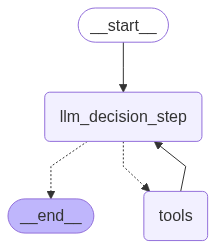

In [27]:
from IPython.display import Image,display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [28]:
message=[HumanMessage(content="What is 2 times of narendramodi's age?")]

In [29]:
response=react_graph.invoke({"messages":message})


In [30]:
#use OPEN AI LLM which is smart enought to answer this corectly, when we use free tool like GROQ it is unable to pic this up
#llm=ChatOpenAI()
llm=ChatGroq(model="deepseek-r1-distill-llama-70b")
response["messages"][-1].content

"Narendra Modi's age in 2023 is 73 years old. \n\nTo calculate 2 times his age:\n73 × 2 = 146\n\nSo, 2 times Narendra Modi's age is **146**."

In [31]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 times of narendramodi's age?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (bcvjwza3w)
 Call ID: bcvjwza3w
  Args:
    query: Narendra Modi age 2023
================================= Tool Message =================================
Name: duckduckgo_search

What is PM Narendra Modi's age in 2023? PM Narendra Modi's age in 2023 is 73 years old as of September 2023. How can I contact Prime Minister of India? Place a call to the Prime Minister's office at 011-230114547. You can also send a fax at 011-23019545 or 011-23016857. The "011" in the phone numbers listed is the area code for New Delhi ... List of all Prime Ministers of India till 2025: Narendra Modi is the current and 14th Prime Minister of India who assumed office on 10 June 2024. Jawaharlal Nehru is the first and the longest ... Narendra Modi (born September 17, 1950, Vadnag

In [32]:
#do not use duct use LIst, Tuple
message=[HumanMessage(content="tell me about yourself with your name and origin")]

In [33]:
response=react_graph.invoke({"messages":message})

In [34]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

tell me about yourself with your name and origin
================================== Ai Message ==================================

I'm an AI assistant created to help with a wide range of tasks, from answering questions to providing information and assisting with problems. My purpose is to make your experience as helpful and positive as possible. If you have any questions or need assistance, feel free to ask!


In [49]:
import requests
from langchain.tools import tool

@tool
def booking_search(location: str) -> str:
    """You are a expert in find hotel and  use this tool for a hotel booking, after this according to this dates go to Flight booking tool to choose flight for these dates, take help from flight booking too to book flights"""
    url = "https://booking-com.p.rapidapi.com/v1/hotels/search"
    headers = {
        "X-RapidAPI-Key": "2cc4ba1209msh5e5edb95001c68cp196f6fjsn6be5b8f52955",
        "X-RapidAPI-Host": "booking-com.p.rapidapi.com"
    }
    params = {
        "dest_type": "city",
        "name": location,
        "checkin_date": "2025-07-10",
        "checkout_date": "2025-07-15",
        "adults_number": 2,
        "locale": "en-gb",
        "units": "metric"
    }

    res = requests.get(url, headers=headers, params=params)
    hotels = res.json().get("result", [])[:3]
    return "\n".join([f"{h['hotel_name']}, {h['address']}" for h in hotels])

In [50]:
booking_search("LA")


''

In [59]:
@tool
def overpass_hotel_search(city: str) -> str:
    """You are a expert in find hotel and  use this tool for a hotel booking, after this according to this dates go to Flight booking tool to choose flight for these dates, take help from flight booking too to book flights"""
    query = f"""
    [out:json];
    area[name="{city}"]->.searchArea;
    (
      node["tourism"="hotel"](area.searchArea);
    );
    out body;
    """
    response = requests.get("https://overpass-api.de/api/interpreter", params={"data": query})
    data = response.json()
    hotels = data.get("elements", [])[:5]
    return "\n".join([f"{h.get('tags', {}).get('name', 'Unnamed Hotel')} (lat: {h['lat']}, lon: {h['lon']})" for h in hotels])


In [60]:
overpass_hotel_search("singapore")

''

In [61]:
query = f"""
    [out:json];
    area[name="singapore"]->.searchArea;
    (
      node["tourism"="hotel"](area.searchArea);
    );
    out body;
    """
response = requests.get("https://overpass-api.de/api/interpreter", params={"data": query})
print(f"Status Code: {response.status_code}")
print(f"Response Text: {response.text[:200]}")  # First 200 chars for brevity
if response.status_code != 200:
    raise Exception(f"API request failed: {response.status_code} - {response.text}")

Status Code: 200
Response Text: {
  "version": 0.6,
  "generator": "Overpass API 0.7.62.7 375dc00a",
  "osm3s": {
    "timestamp_osm_base": "2025-06-28T01:51:45Z",
    "timestamp_areas_base": "2025-06-27T22:18:46Z",
    "copyright":


In [64]:
import requests
import os

AMADEUS_API_KEY = "MqV7kWkk9tXOxXXACnxQQGGTiPxPuJW9"
AMADEUS_API_SECRET = "JFupVrYyc83qwGGw"

def get_amadeus_token():
    url = "https://test.api.amadeus.com/v1/security/oauth2/token"
    payload = {
        "grant_type": "client_credentials",
        "client_id": AMADEUS_API_KEY,
        "client_secret": AMADEUS_API_SECRET
    }
    headers = { "Content-Type": "application/x-www-form-urlencoded" }

    res = requests.post(url, data=payload, headers=headers)
    return res.json().get("access_token")

get_amadeus_token()


'uCFEuZbake6zzBK8Vo4zgYWkZHEE'

In [74]:
def search_hotels(city_code: str, check_in: str, check_out: str):
    token = get_amadeus_token()
    url = "https://test.api.amadeus.com/v1/reference-data/locations/cities?keyword=PAR&max=100" # <-- FIXED

    params = {
        "cityCode": city_code,
        "checkInDate": check_in,
        "checkOutDate": check_out,
        "adults": 2,
        "roomQuantity": 1,
        "radius": 5,
        "radiusUnit": "KM",
        "paymentPolicy": "NONE",
        "includeClosed": "false",
        "bestRateOnly": "true",
        "view": "FULL",
        "sort": "PRICE"
    }
    headers = {"Authorization": f"Bearer {token}"}
    res = requests.get(url, params=params, headers=headers)

    try:
        res.raise_for_status()
        return res.json()
    except requests.exceptions.HTTPError as e:
        print("🔴 HTTP Error:", res.status_code)
        print("🔍 Response Text:", res.text)
        raise e



search_hotels("PAR","2025-07-01","2025-07-10")

🔴 HTTP Error: 400
🔍 Response Text: {
  "errors" : [ {
    "code" : 572,
    "title" : "INVALID OPTION",
    "detail" : "Query parameter not supported",
    "source" : {
      "parameter" : "roomQuantity"
    },
    "status" : 400
  }, {
    "code" : 572,
    "title" : "INVALID OPTION",
    "detail" : "Query parameter not supported",
    "source" : {
      "parameter" : "cityCode"
    },
    "status" : 400
  }, {
    "code" : 572,
    "title" : "INVALID OPTION",
    "detail" : "Query parameter not supported",
    "source" : {
      "parameter" : "adults"
    },
    "status" : 400
  }, {
    "code" : 572,
    "title" : "INVALID OPTION",
    "detail" : "Query parameter not supported",
    "source" : {
      "parameter" : "sort"
    },
    "status" : 400
  }, {
    "code" : 572,
    "title" : "INVALID OPTION",
    "detail" : "Query parameter not supported",
    "source" : {
      "parameter" : "checkInDate"
    },
    "status" : 400
  }, {
    "code" : 572,
    "title" : "INVALID OPTION",


HTTPError: 400 Client Error: Bad Request for url: https://test.api.amadeus.com/v1/reference-data/locations/cities?keyword=PAR&max=100&cityCode=PAR&checkInDate=2025-07-01&checkOutDate=2025-07-10&adults=2&roomQuantity=1&radius=5&radiusUnit=KM&paymentPolicy=NONE&includeClosed=false&bestRateOnly=true&view=FULL&sort=PRICE

In [75]:
from overpass_hotel_search import overpass_hotel_search  # Assume imported
city = "Paris"
amadeus_result = search_hotels("PAR", "2025-07-01", "2025-07-10")
overpass_result = overpass_hotel_search(city)
print("Amadeus Hotels:", amadeus_result)
print("Overpass Hotels:", overpass_result)

ModuleNotFoundError: No module named 'overpass_hotel_search'

In [73]:
def verify_city_code(city_code: str, token: str) -> dict:
    url = "https://test.api.amadeus.com/v1/reference-data/locations/cities?keyword=PAR&max=100"
    params = {"keyword": city_code}
    headers = {"Authorization": f"Bearer {token}"}
    response = requests.get(url, params=params, headers=headers)
    response.raise_for_status()
    return response.json()

token = get_amadeus_token()
rprint(verify_city_code("PAR", token))

{
    'meta': {
        'count': 100,
        'links': {'self': 'https://test.api.amadeus.com/v1/reference-data/locations/cities?keyword=PAR&max=100'}
    },
    'data': [
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Ampara',
            'iataCode': 'ADP',
            'address': {'countryCode': 'LK', 'stateCode': 'LK-ZZZ'},
            'geoCode': {'latitude': 7.29754, 'longitude': 81.68202}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Apartado',
            'iataCode': 'APO',
            'address': {'countryCode': 'CO', 'stateCode': 'CO-ZZZ'},
            'geoCode': {'latitude': 7.88299, 'longitude': -76.62587}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Alto Parnaiba',
            'iataCode': 'APY',
            'address': {'countryCode': 'BR', 'stateCode': 'BR-MA'},
            'geoCode': {}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Avon Park',
            'iataCode': 'AVO',
            'address': {'countryCode': 'US', 'stateCode': 'US-FL'},
            'geoCode': {'latitude': 27.59587, 'longitude': -81.50619}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Katmai National Park',
            'iataCode': 'BKF',
            'address': {'countryCode': 'US', 'stateCode': 'US-AK'},
            'geoCode': {}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Paris',
            'iataCode': 'PAR',
            'address': {'countryCode': 'FR', 'stateCode': 'FR-75'},
            'geoCode': {'latitude': 48.85341, 'longitude': 2.3488}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'College Park',
            'iataCode': 'CGS',
            'address': {'countryCode': 'US', 'stateCode': 'US-MD'},
            'geoCode': {'latitude': 38.98067, 'longitude': -76.93692}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Parauapebas',
            'iataCode': 'CKS',
            'address': {'countryCode': 'BR', 'stateCode': 'BR-PA'},
            'geoCode': {'latitude': -6.0675, 'longitude': -49.90222}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Sparta',
            'iataCode': 'CMY',
            'address': {'countryCode': 'US', 'stateCode': 'US-WI'},
            'geoCode': {'latitude': 43.94413, 'longitude': -90.81291}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Chaparral',
            'iataCode': 'CPL',
            'address': {'countryCode': 'CO', 'stateCode': 'CO-ZZZ'},
            'geoCode': {'latitude': 3.72315, 'longitude': -75.48316}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Debepare',
            'iataCode': 'DBP',
            'address': {'countryCode': 'PG', 'stateCode': 'PG-ZZZ'},
            'geoCode': {}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Deparijo',
            'iataCode': 'DEP',
            'address': {'countryCode': 'IN', 'stateCode': 'IN-AR'},
            'geoCode': {}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Death Valley Nat. Park',
            'iataCode': 'DTH',
            'address': {'countryCode': 'US', 'stateCode': 'US-CA'},
            'geoCode': {}
        },
        {
            'type': 'location',
            'subType': 'city',
            'name': 'Paratebueno',
            'iataCode': 'EUO',
            'address': {'countryCode': 'CO', 'stateCode': 'CO-ZZZ'},
            'geoCode': {'latitude': 4.37575, 'longitude': -73.21547}
        },
        {
            'typ